In [1]:
BASE_PATH = "../data"

In [2]:
# See https://detectron2.readthedocs.io/tutorials/install.html for instructions
# %%capture
# !pip install pyyaml==5.1 --q
# !python -m pip install 'git+https://github.com/facebookresearch/detectron2.git@v0.5' --q
!pip install transformers --q

In [3]:
import torch, torchvision
import matplotlib.pyplot as plt
import json
import cv2
import numpy as np
from copy import deepcopy
from glob import glob
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split

# VisualBERT (crash)

In [5]:
from detectron2.modeling import build_model
from detectron2.checkpoint import DetectionCheckpointer
from detectron2.structures.image_list import ImageList
from detectron2.data import transforms as T
from detectron2.modeling.box_regression import Box2BoxTransform
from detectron2.modeling.roi_heads.fast_rcnn import FastRCNNOutputs
from detectron2.structures.boxes import Boxes
from detectron2.layers import nms
from detectron2 import model_zoo
from detectron2.config import get_cfg

In [6]:
torch.cuda.is_available()

True

In [7]:
cfg_path = "COCO-InstanceSegmentation/mask_rcnn_R_101_FPN_3x.yaml"

def load_config_and_model_weights(cfg_path):
    cfg = get_cfg()
    cfg.merge_from_file(model_zoo.get_config_file(cfg_path))

    # ROI HEADS SCORE THRESHOLD
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5

    # Comment the next line if you're using 'cuda'
    cfg['MODEL']['DEVICE']='cpu'

    cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(cfg_path)

    return cfg

cfg = load_config_and_model_weights(cfg_path)

In [8]:
def get_model(cfg):
    # build model
    model = build_model(cfg)

    # load weights
    checkpointer = DetectionCheckpointer(model)
    checkpointer.load(cfg.MODEL.WEIGHTS)

    # eval mode
    model.eval()
    return model

model = get_model(cfg)

  proposal_generator.anchor_generator.cell_anchors.{0, 1, 2, 3, 4}


In [9]:
train_df = pd.read_csv(f"{BASE_PATH}/ristek-datathon-2022/train.csv")
train_df.head()

created_at                   id     user_id  \
0  2020-02-23 04:06:39+00:00  1231430140824973313   133931409   
1  2020-01-05 01:46:46+00:00  1213637932411580417   253063316   
2  2020-01-18 06:22:09+00:00  1218418277946396673    64318803   
3  2020-02-22 23:38:00+00:00  1231362534717837313    17383917   
4  2019-12-17 10:54:31+00:00  1206890412574568449  3102973556   

                       user_name  \
0               r0b1 sur1a (黄玉春)   
1  Beradaptasi di Era Pandemi ☀️   
2                          rywyu   
3                      ICALIZERS   
4                             AN   

                                                 url  \
0  https://twitter.com/R0b1Sur1a/status/123143014...   
1  https://twitter.com/MarikaRahman_/status/12136...   
2  https://twitter.com/rywyu/status/1218418277946...   
3  https://twitter.com/icalizers/status/123136253...   
4  https://twitter.com/lokbin103/status/120689041...   

                                                text                media  \
0  Akhirnya sampai juga setelah menerobos banjir....  ERbrKgFU4AAnADb.jpg   
1  Kemekes RI, IDI Banten, IBI Banten dan PPNI Ba...  ENe1HUVUEAANLFT.jpg   
2  Dikarenakan cikini rada2 banjir tdi pagi hingg...  EOiw80RU0AcJ4CI.jpg   
3  #sperma TT dikala warga jakarta sedang prihati...  ERatrt9UYAAtLMI.jpg   
4  KUIS!\n\nJakarta banjir parah hari ini, pertan...  EL-8Z-vUcAIiIlV.jpg   

   label  
0      0  
1      0  
2      0  
3      0  
4      0

In [10]:
train_df.shape

(1518, 8)

In [17]:
def stratified_sample_df(df, col, n_samples):
  sample_train, drop_train = train_test_split(train_df, train_size=n_samples, stratify=train_df["label"])
  return sample_train

In [25]:
sampled_train_df = stratified_sample_df(train_df, "label", 100)
sampled_train_df.shape

(100, 8)

In [26]:
sampled_train_df.label.value_counts()

label
0    79
1    21
Name: count, dtype: int64

In [27]:
images = []
texts = []
for index, row in train_df.iterrows():
  img = plt.imread(f'{BASE_PATH}/ristek-datathon-2022/Image/{row["media"]}')

  # Detectron expects BGR images
  img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
  images.append(img_bgr)

  text = row["text"]
  texts.append(text)

In [ ]:
# # save images and texts to pickle
# import pickle

# with open(f"{BASE_PATH}/ristek-datathon-2022/images.pkl", "wb") as f:
#   pickle.dump(images, f)

# with open(f"{BASE_PATH}/ristek-datathon-2022/texts.pkl", "wb") as f:
#   pickle.dump(texts, f)

In [28]:
# images = pickle.load(open(f"{BASE_PATH}/ristek-datathon-2022/images.pkl", "rb"))
# texts = pickle.load(open(f"{BASE_PATH}/ristek-datathon-2022/texts.pkl", "rb"))
img = images[0]
text = texts[0]

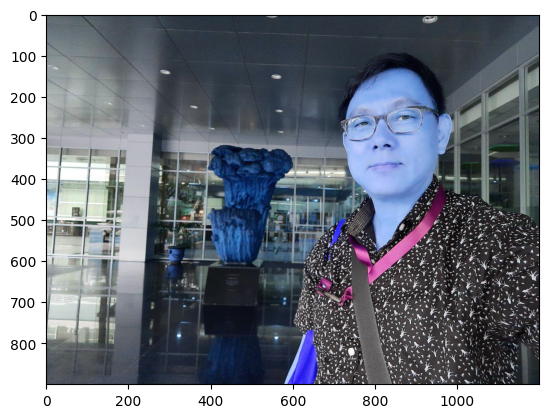

In [29]:
plt.imshow(img)
plt.show()

In [ ]:
def prepare_image_inputs(cfg, img_list):
    # Resizing the image according to the configuration
    transform_gen = T.ResizeShortestEdge(
                [cfg.INPUT.MIN_SIZE_TEST, cfg.INPUT.MIN_SIZE_TEST], cfg.INPUT.MAX_SIZE_TEST
            )
    img_list = [transform_gen.get_transform(img).apply_image(img) for img in img_list]

    # Convert to C,H,W format
    convert_to_tensor = lambda x: torch.Tensor(x.astype("float32").transpose(2, 0, 1))

    batched_inputs = [{"image":convert_to_tensor(img), "height": img.shape[0], "width": img.shape[1]} for img in img_list]

    # Normalizing the image
    num_channels = len(cfg.MODEL.PIXEL_MEAN)
    pixel_mean = torch.Tensor(cfg.MODEL.PIXEL_MEAN).view(num_channels, 1, 1)
    pixel_std = torch.Tensor(cfg.MODEL.PIXEL_STD).view(num_channels, 1, 1)
    normalizer = lambda x: (x - pixel_mean) / pixel_std
    images = [normalizer(x["image"]) for x in batched_inputs]

    # Convert to ImageList
    images =  ImageList.from_tensors(images,model.backbone.size_divisibility)

    return images, batched_inputs

images_inputs, batched_inputs = prepare_image_inputs(cfg, images)

In [ ]:
def get_features(model, images):
    features = model.backbone(images.tensor)
    return features

features = get_features(model, images_inputs)

In [ ]:
def get_proposals(model, images, features):
    proposals, _ = model.proposal_generator(images, features)
    return proposals

proposals = get_proposals(model, images_inputs, features)

In [ ]:
def get_box_features(model, features, proposals):
    features_list = [features[f] for f in ['p2', 'p3', 'p4', 'p5']]
    box_features = model.roi_heads.box_pooler(features_list, [x.proposal_boxes for x in proposals])
    box_features = model.roi_heads.box_head.flatten(box_features)
    box_features = model.roi_heads.box_head.fc1(box_features)
    box_features = model.roi_heads.box_head.fc_relu1(box_features)
    box_features = model.roi_heads.box_head.fc2(box_features)

    box_features = box_features.reshape(2, 1000, 1024) # depends on your config and batch size
    return box_features, features_list

box_features, features_list = get_box_features(model, features, proposals)

In [ ]:
def get_prediction_logits(model, features_list, proposals):
    cls_features = model.roi_heads.box_pooler(features_list, [x.proposal_boxes for x in proposals])
    cls_features = model.roi_heads.box_head(cls_features)
    pred_class_logits, pred_proposal_deltas = model.roi_heads.box_predictor(cls_features)
    return pred_class_logits, pred_proposal_deltas

pred_class_logits, pred_proposal_deltas = get_prediction_logits(model, features_list, proposals)

In [ ]:
def get_box_scores(cfg, pred_class_logits, pred_proposal_deltas):
    box2box_transform = Box2BoxTransform(weights=cfg.MODEL.ROI_BOX_HEAD.BBOX_REG_WEIGHTS)
    smooth_l1_beta = cfg.MODEL.ROI_BOX_HEAD.SMOOTH_L1_BETA

    outputs = FastRCNNOutputs(
        box2box_transform,
        pred_class_logits,
        pred_proposal_deltas,
        proposals,
        smooth_l1_beta,
    )

    boxes = outputs.predict_boxes()
    scores = outputs.predict_probs()
    image_shapes = outputs.image_shapes

    return boxes, scores, image_shapes

boxes, scores, image_shapes = get_box_scores(cfg, pred_class_logits, pred_proposal_deltas)

In [ ]:
def get_output_boxes(boxes, batched_inputs, image_size):
    proposal_boxes = boxes.reshape(-1, 4).clone()
    scale_x, scale_y = (batched_inputs["width"] / image_size[1], batched_inputs["height"] / image_size[0])
    output_boxes = Boxes(proposal_boxes)

    output_boxes.scale(scale_x, scale_y)
    output_boxes.clip(image_size)

    return output_boxes

output_boxes = [get_output_boxes(boxes[i], batched_inputs[i], proposals[i].image_size) for i in range(len(proposals))]

In [ ]:
def select_boxes(cfg, output_boxes, scores):
    test_score_thresh = cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST
    test_nms_thresh = cfg.MODEL.ROI_HEADS.NMS_THRESH_TEST
    cls_prob = scores.detach()
    cls_boxes = output_boxes.tensor.detach().reshape(1000,80,4)
    max_conf = torch.zeros((cls_boxes.shape[0]))
    for cls_ind in range(0, cls_prob.shape[1]-1):
        cls_scores = cls_prob[:, cls_ind+1]
        det_boxes = cls_boxes[:,cls_ind,:]
        keep = np.array(nms(det_boxes, cls_scores, test_nms_thresh))
        max_conf[keep] = torch.where(cls_scores[keep] > max_conf[keep], cls_scores[keep], max_conf[keep])
    keep_boxes = torch.where(max_conf >= test_score_thresh)[0]
    return keep_boxes, max_conf

temp = [select_boxes(cfg, output_boxes[i], scores[i]) for i in range(len(scores))]
keep_boxes, max_conf = [],[]
for keep_box, mx_conf in temp:
    keep_boxes.append(keep_box)
    max_conf.append(mx_conf)

In [ ]:
MIN_BOXES=10
MAX_BOXES=100
def filter_boxes(keep_boxes, max_conf, min_boxes, max_boxes):
    if len(keep_boxes) < min_boxes:
        keep_boxes = np.argsort(max_conf).numpy()[::-1][:min_boxes]
    elif len(keep_boxes) > max_boxes:
        keep_boxes = np.argsort(max_conf).numpy()[::-1][:max_boxes]
    return keep_boxes

keep_boxes = [filter_boxes(keep_box, mx_conf, MIN_BOXES, MAX_BOXES) for keep_box, mx_conf in zip(keep_boxes, max_conf)]

In [ ]:
def get_visual_embeds(box_features, keep_boxes):
    return box_features[keep_boxes.copy()]

visual_embeds = [get_visual_embeds(box_feature, keep_box) for box_feature, keep_box in zip(box_features, keep_boxes)]

# ViLT

In [4]:
train_df = pd.read_csv(f"{BASE_PATH}/ristek-datathon-2022/train.csv")
train_df.head()

created_at                   id     user_id  \
0  2020-02-23 04:06:39+00:00  1231430140824973313   133931409   
1  2020-01-05 01:46:46+00:00  1213637932411580417   253063316   
2  2020-01-18 06:22:09+00:00  1218418277946396673    64318803   
3  2020-02-22 23:38:00+00:00  1231362534717837313    17383917   
4  2019-12-17 10:54:31+00:00  1206890412574568449  3102973556   

                       user_name  \
0               r0b1 sur1a (黄玉春)   
1  Beradaptasi di Era Pandemi ☀️   
2                          rywyu   
3                      ICALIZERS   
4                             AN   

                                                 url  \
0  https://twitter.com/R0b1Sur1a/status/123143014...   
1  https://twitter.com/MarikaRahman_/status/12136...   
2  https://twitter.com/rywyu/status/1218418277946...   
3  https://twitter.com/icalizers/status/123136253...   
4  https://twitter.com/lokbin103/status/120689041...   

                                                text                media  \
0  Akhirnya sampai juga setelah menerobos banjir....  ERbrKgFU4AAnADb.jpg   
1  Kemekes RI, IDI Banten, IBI Banten dan PPNI Ba...  ENe1HUVUEAANLFT.jpg   
2  Dikarenakan cikini rada2 banjir tdi pagi hingg...  EOiw80RU0AcJ4CI.jpg   
3  #sperma TT dikala warga jakarta sedang prihati...  ERatrt9UYAAtLMI.jpg   
4  KUIS!\n\nJakarta banjir parah hari ini, pertan...  EL-8Z-vUcAIiIlV.jpg   

   label  
0      0  
1      0  
2      0  
3      0  
4      0

In [5]:
train_df.shape

(1518, 8)

In [6]:

def stratified_sample_df(df, col, n_samples):
  sample_train, drop_train = train_test_split(train_df, train_size=n_samples, stratify=train_df["label"])
  return sample_train

In [7]:
sampled_train_df = stratified_sample_df(train_df, "label", 100)
sampled_train_df.shape

(100, 8)

In [8]:
sampled_train_df.label.value_counts()

label
0    79
1    21
Name: count, dtype: int64

In [9]:
images = []
texts = []
for index, row in train_df.iterrows():
  img = plt.imread(f'{BASE_PATH}/ristek-datathon-2022/Image/{row["media"]}')

  # Detectron expects BGR images
  img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
  images.append(img_bgr)

  text = row["text"]
  texts.append(text)

In [11]:
# # save images and texts to pickle
# import pickle

# with open(f"{BASE_PATH}/ristek-datathon-2022/images.pkl", "wb") as f:
#   pickle.dump(images, f)

# with open(f"{BASE_PATH}/ristek-datathon-2022/texts.pkl", "wb") as f:
#   pickle.dump(texts, f)

In [10]:
# images = pickle.load(open(f"{BASE_PATH}/ristek-datathon-2022/images.pkl", "rb"))
# texts = pickle.load(open(f"{BASE_PATH}/ristek-datathon-2022/texts.pkl", "rb"))
img = images[0]
text = texts[0]

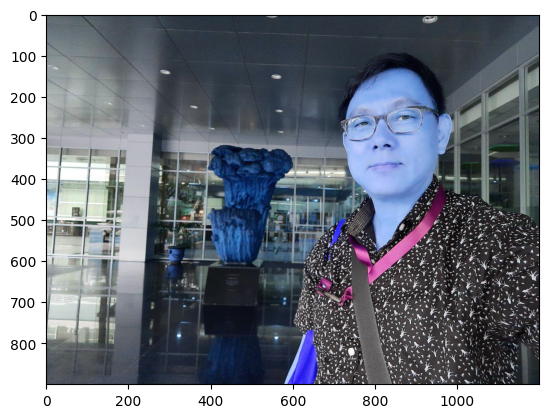

In [11]:
plt.imshow(img)
plt.show()

In [12]:
from transformers import ViltConfig, ViltProcessor, ViltModel

In [13]:
config = ViltConfig.from_pretrained("dandelin/vilt-b32-finetuned-vqa")

In [14]:
processor = ViltProcessor.from_pretrained("dandelin/vilt-b32-mlm")
model = ViltModel.from_pretrained("dandelin/vilt-b32-mlm")

In [ ]:
inputs = processor(images, texts, return_tensors="pt", padding="max_length", truncation=True, max_length=128)
outputs = model(**inputs)
last_hidden_states = outputs.last_hidden_state

In [1]:
len(last_hidden_states)

NameError: name 'last_hidden_states' is not defined